# YOLOv8 Tabanlı Derin Öğrenme Yaklaşımlarıyla Beyin Tümörü Tespiti

**İstanbul Topkapı Üniversitesi — Derin Öğrenme Final Ödevi**

Bu not defteri, Ultralytics tarafından sağlanan Brain Tumor Detection veri seti üzerinde YOLOv8n modeli eğiterek MR görüntülerinde beyin tümörü tespiti gerçekleştirmektedir.

**İçindekiler:**
1. Ortam Kurulumu
2. Veri Seti Keşfi
3. YAML Kontrolü
4. Model Eğitimi
5. Değerlendirme Metrikleri
6. Çıkarım ve Görselleştirme
7. Sonuç Özeti

## 1. Ortam Kurulumu

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)

# Proje kök dizini
PROJECT_DIR = Path('.').resolve()
DATA_DIR    = PROJECT_DIR / 'brain-tumor'

TRAIN_IMG_DIR = DATA_DIR / 'images' / 'train'
VAL_IMG_DIR   = DATA_DIR / 'images' / 'val'
TRAIN_LBL_DIR = DATA_DIR / 'labels' / 'train'
VAL_LBL_DIR   = DATA_DIR / 'labels' / 'val'

CLASS_NAMES = {0: 'negative', 1: 'positive'}

print(f"Proje dizini : {PROJECT_DIR}")
print(f"Veri dizini  : {DATA_DIR}")

Proje dizini : C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj
Veri dizini  : C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj\brain-tumor


Torch kontrolü (ultralytics YOLO buna dependent)

In [2]:
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"CUDA version   : {torch.version.cuda}")

CUDA available : True
GPU            : NVIDIA GeForce RTX 5060 Ti
CUDA version   : 13.0


## 2. Veri Seti Keşfi

In [3]:
train_images = sorted(TRAIN_IMG_DIR.glob('*.jpg'))
val_images   = sorted(VAL_IMG_DIR.glob('*.jpg'))

print("=" * 40)
print("Veri Seti İstatistikleri")
print("=" * 40)
print(f"Eğitim görüntüsü    : {len(train_images)}")
print(f"Doğrulama görüntüsü : {len(val_images)}")
print(f"Toplam              : {len(train_images) + len(val_images)}")
print(f"Sınıflar            : {list(CLASS_NAMES.values())}")

Veri Seti İstatistikleri
Eğitim görüntüsü    : 893
Doğrulama görüntüsü : 223
Toplam              : 1116
Sınıflar            : ['negative', 'positive']


In [4]:
def count_classes_in_labels(label_dir):
    """Her sınıfın bounding box sayısını döndürür."""
    counts = {0: 0, 1: 0}
    for lf in Path(label_dir).glob('*.txt'):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    counts[cls] = counts.get(cls, 0) + 1
    return counts

train_counts = count_classes_in_labels(TRAIN_LBL_DIR)
val_counts   = count_classes_in_labels(VAL_LBL_DIR)

print("Eğitim seti sınıf dağılımı :", {CLASS_NAMES[k]: v for k, v in train_counts.items()})
print("Doğrulama seti sınıf dağılımı:", {CLASS_NAMES[k]: v for k, v in val_counts.items()})

Eğitim seti sınıf dağılımı : {'negative': 437, 'positive': 488}
Doğrulama seti sınıf dağılımı: {'negative': 154, 'positive': 87}


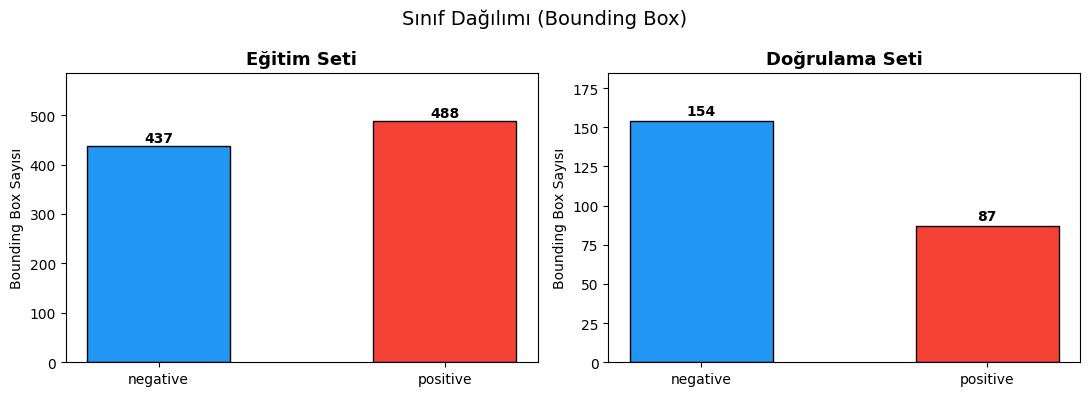

In [5]:
# Sınıf dağılımı grafiği
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2196F3', '#F44336']

for ax, counts, title in zip(
    axes,
    [train_counts, val_counts],
    ['Eğitim Seti', 'Doğrulama Seti']
):
    vals = [counts.get(0, 0), counts.get(1, 0)]
    bars = ax.bar(list(CLASS_NAMES.values()), vals, color=colors, width=0.5, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Bounding Box Sayısı')
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(v), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Sınıf Dağılımı (Bounding Box)', fontsize=14)
plt.tight_layout()
plt.show()

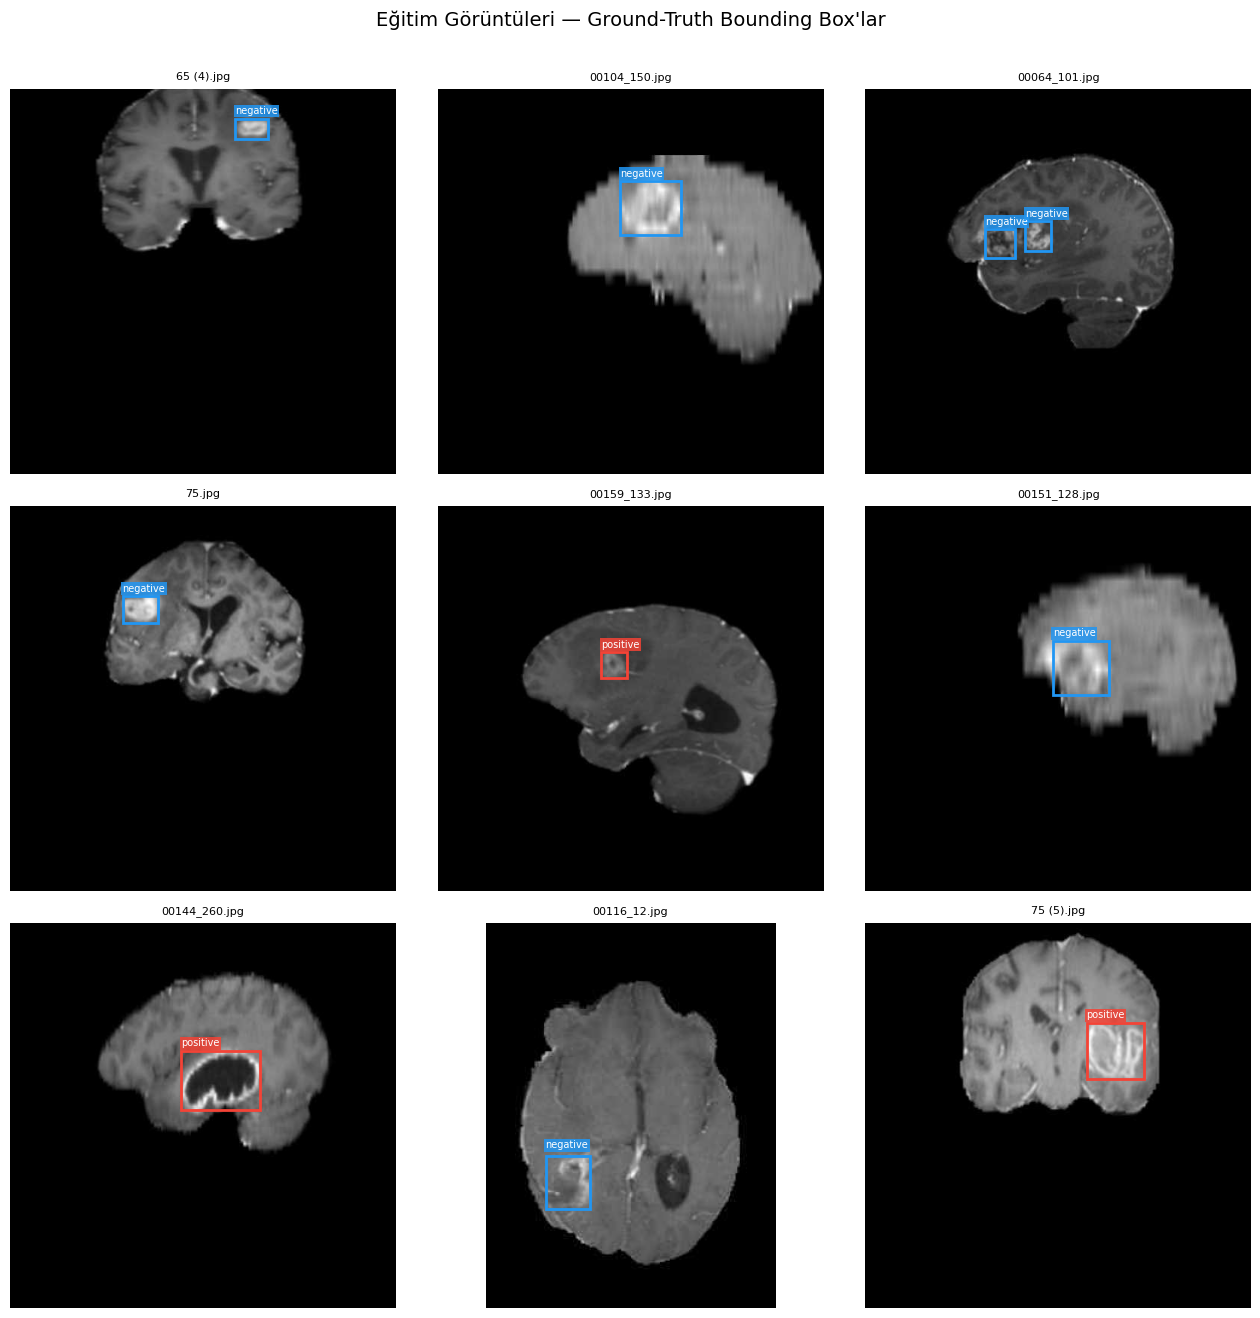

In [6]:
def draw_boxes_on_ax(img_path, label_path, ax):
    """Görüntüyü ve ground-truth bounding box'ları matplotlib eksenine çizer."""
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    ax.imshow(img)

    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls  = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                color = '#F44336' if cls == 1 else '#2196F3'
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(
                    x1, max(y1 - 6, 0), CLASS_NAMES[cls],
                    fontsize=7, color='white',
                    bbox=dict(facecolor=color, pad=1, edgecolor='none', alpha=0.85)
                )
    ax.axis('off')

sample_imgs = random.sample(train_images, min(9, len(train_images)))

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for img_path, ax in zip(sample_imgs, axes.flatten()):
    lbl_path = TRAIN_LBL_DIR / (img_path.stem + '.txt')
    draw_boxes_on_ax(img_path, lbl_path, ax)
    ax.set_title(img_path.name[:18], fontsize=8)

plt.suptitle('Eğitim Görüntüleri — Ground-Truth Bounding Box\'lar', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. YAML Kontrolü

Veri setinin içindeki brain-tumor.yaml dosyasi doğrudan kullanılacak.

In [7]:
yaml_path = DATA_DIR / 'brain-tumor.yaml'

print(f'YAML dosyasi: {yaml_path}')
print('-' * 40)
with open(yaml_path, encoding='utf-8') as f:
    print(f.read())

YAML dosyasi: C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj\brain-tumor\brain-tumor.yaml
----------------------------------------
# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Brain-tumor dataset by Ultralytics
# Documentation: https://docs.ultralytics.com/datasets/detect/brain-tumor/
# Example usage: yolo train data=brain-tumor.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── brain-tumor ← downloads here (4.21 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: brain-tumor # dataset root dir
train: images/train # train images (relative to 'path') 893 images
val: images/val # val images (relative to 'path') 223 images
test: # test images (relative to 'path')

# Classes
names:
  0: negative
  1: positive

# Download script/URL (optional)
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip


## 4. Model Eğitimi

In [30]:
model = YOLO('yolov8n.pt')

train_results = model.train(
    data=str(yaml_path),
    epochs=100,
    #patience=20, #early stopping
    imgsz=640, 
    batch=16, #batching for memory
    name='brain_tumor_yolov8n',
    project='runs',
    exist_ok=True,
    verbose=True,
    device=0,
    plots=True,
    workers=0, 
)

Ultralytics 8.4.75  Python-3.13.14 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj\brain-tumor\brain-tumor.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_y

Save dir: C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj\runs\detect\runs\brain_tumor_yolov8n


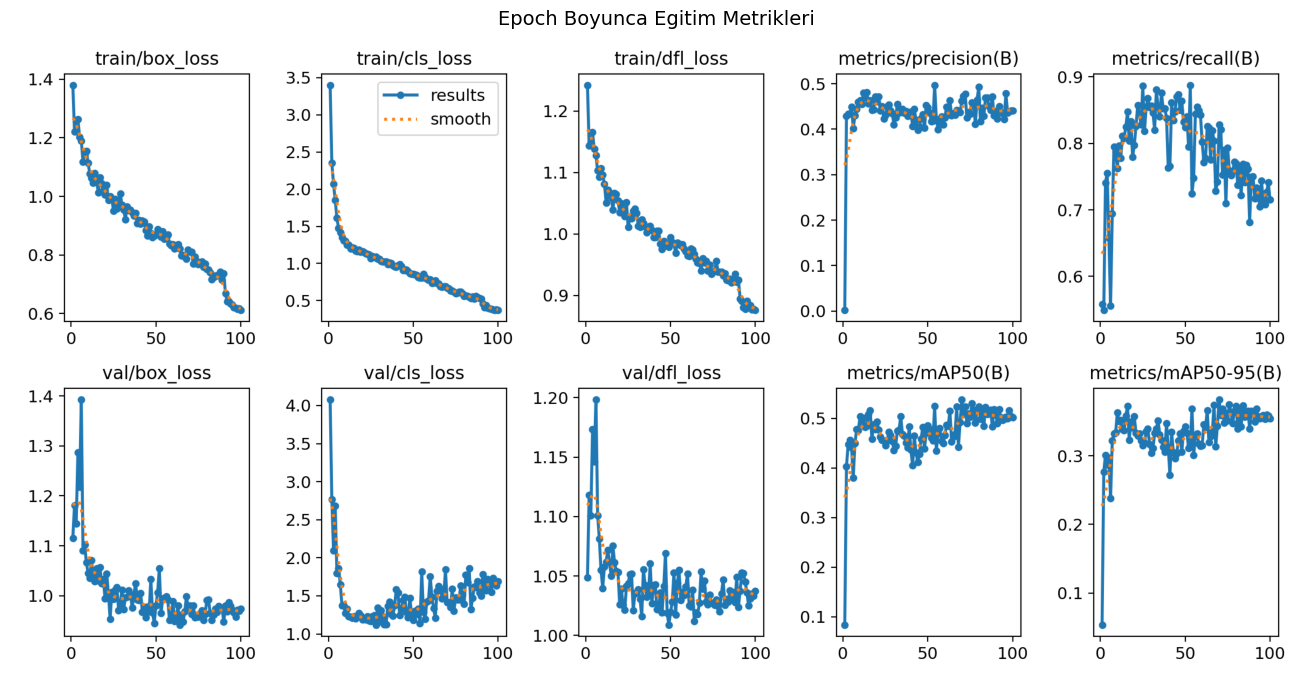

In [31]:
try:
    save_dir = Path(train_results.save_dir) # type: ignore
except NameError:
    # Training was run in a previous session - find the folder automatically
    candidates = list(PROJECT_DIR.rglob('brain_tumor_yolov8n'))
    save_dir = sorted(candidates)[-1]

print(f'Save dir: {save_dir}')

results_img_path = save_dir / 'results.png'
if results_img_path.exists():
    img = Image.open(results_img_path)
    plt.figure(figsize=(16, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Epoch Boyunca Egitim Metrikleri', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f'Sonuc gorseli bulunamadi: {results_img_path}')

Sadece validation kısmı(tekrar run etmeden best weightleri kullanıp validation.

In [71]:
best_weights = save_dir / 'weights' / 'best.pt'
trained_model = YOLO(str(best_weights))

metrics = trained_model.val(data=str(yaml_path), verbose=True, exist_ok=True)

Ultralytics 8.4.75  Python-3.13.14 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 59.928.3 MB/s, size: 3.7 KB)
val: Scanning C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj\brain-tumor\labels\val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 71.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 8.9it/s 1.6s0.2s
                   all        223        241      0.462      0.828      0.538      0.382
              negative        142        154      0.605      0.726       0.62      0.432
              positive         81         87      0.319      0.931      0.456      0.332
Speed: 1.2ms preprocess, 1.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\sinan\Documents\Python Projects\main

## 5. Değerlendirme Metrikleri

Eğitim tamamlandıktan sonra en iyi ağırlıklar (`best.pt`) yüklenerek doğrulama seti üzerinde değerlendirme yapılmaktadır.

In [72]:
# Metrik değerlerini çıkar
map50    = float(metrics.box.map50)
map5095  = float(metrics.box.map)
precision = float(metrics.box.mp)   # sınıflar üzerinde ortalama precision
recall    = float(metrics.box.mr)   # sınıflar üzerinde ortalama recall

# Accuracy: confusion matrix köşegeni toplamı / tüm eleman toplamı
cm = metrics.confusion_matrix.matrix  # (nc+1, nc+1) = (3, 3)
accuracy = float(np.diag(cm).sum() / cm.sum())

# F1 skoru (bilgi amaçlı)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

results_df = pd.DataFrame({
    'Metrik': ['Doğruluk (Accuracy)', 'Kesinlik (Precision)', 'Duyarlılık (Recall)',
               'F1 Skoru', 'mAP@0.5', 'mAP@0.5:0.95'],
    'Değer': [f'{accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}',
              f'{f1:.4f}', f'{map50:.4f}', f'{map5095:.4f}']
})

print("=" * 40)
print("Model Performans Metrikleri")
print("=" * 40)
print(results_df.to_string(index=False))

Model Performans Metrikleri
              Metrik  Değer
 Doğruluk (Accuracy) 0.3196
Kesinlik (Precision) 0.4618
 Duyarlılık (Recall) 0.8283
            F1 Skoru 0.5930
             mAP@0.5 0.5380
        mAP@0.5:0.95 0.3819


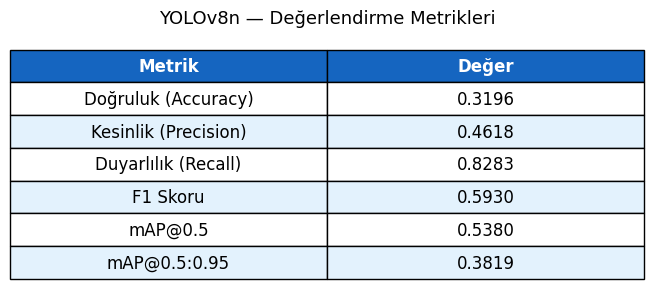

In [73]:
# Metriklerin görsel tablosu
fig, ax = plt.subplots(figsize=(7, 3))
ax.axis('off')
table = ax.table(
    cellText=results_df.values, # type: ignore
    colLabels=results_df.columns, # type: ignore
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E3F2FD')
plt.title('YOLOv8n — Değerlendirme Metrikleri', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

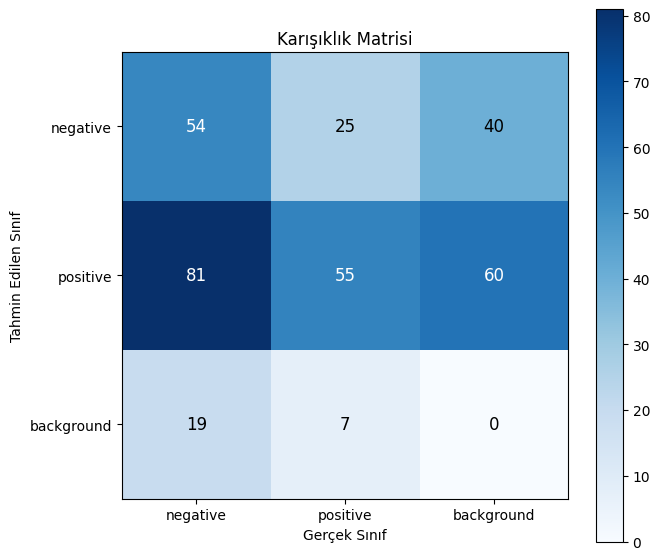

In [74]:
# Karışıklık Matrisi (Confusion Matrix)
# Ultralytics (nc+1)x(nc+1) matris döndürür; son satır/sütun 'background'ı temsil eder
# NOT: Ultralytics matrisi matrix[tahmin, gerçek] olarak saklar -> satır=Tahmin, sütun=Gerçek
cm_labels = [CLASS_NAMES[0], CLASS_NAMES[1], 'background']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set(
    xticks=range(len(cm_labels)),
    yticks=range(len(cm_labels)),
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    xlabel='Gerçek Sınıf',
    ylabel='Tahmin Edilen Sınıf',
    title='Karışıklık Matrisi'
)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]:.0f}',
                ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

## 6. Çıkarım ve Görselleştirme

Doğrulama setinden rastgele seçilen 6 görüntü üzerinde modelin tahminleri gösterilmektedir.

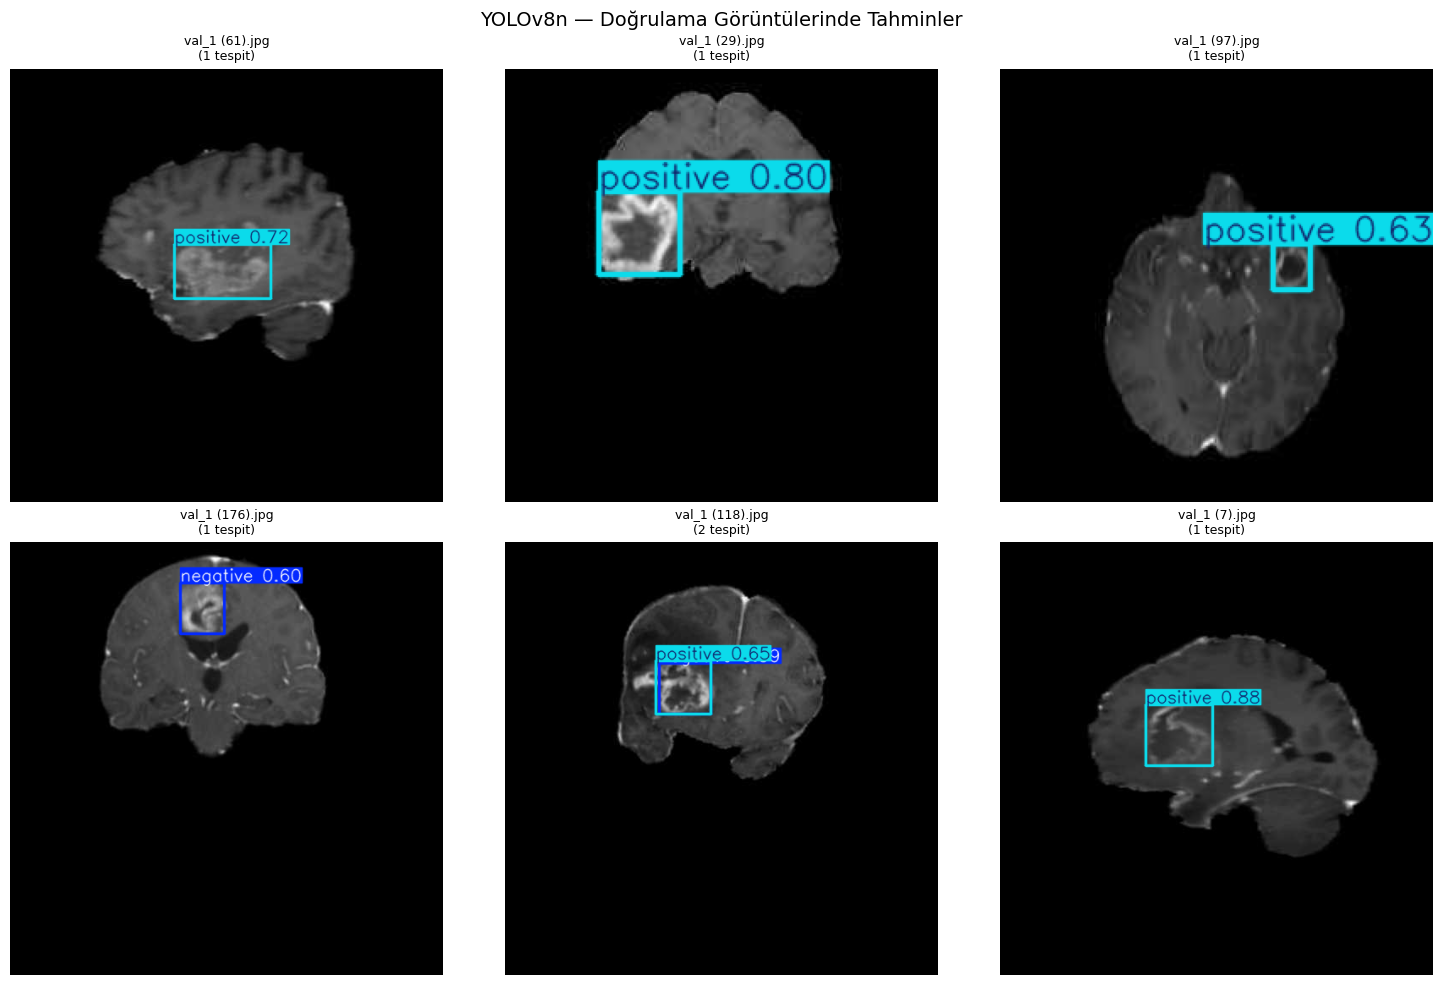

In [75]:
sample_val_imgs = random.sample(val_images, min(6, len(val_images)))

predict_results = trained_model.predict(
    [str(p) for p in sample_val_imgs],
    conf=0.25,
    save=False,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for result, ax in zip(predict_results, axes.flatten()):
    # result.plot() BGR numpy array döndürür → RGB'ye çevir
    annotated_bgr = result.plot()
    annotated_rgb = annotated_bgr[:, :, ::-1]
    ax.imshow(annotated_rgb)
    ax.axis('off')

    n_det = len(result.boxes) if result.boxes is not None else 0
    ax.set_title(f"{Path(result.path).name[:22]}\n({n_det} tespit)", fontsize=9)

plt.suptitle('YOLOv8n — Doğrulama Görüntülerinde Tahminler', fontsize=14)
plt.tight_layout()
plt.show()

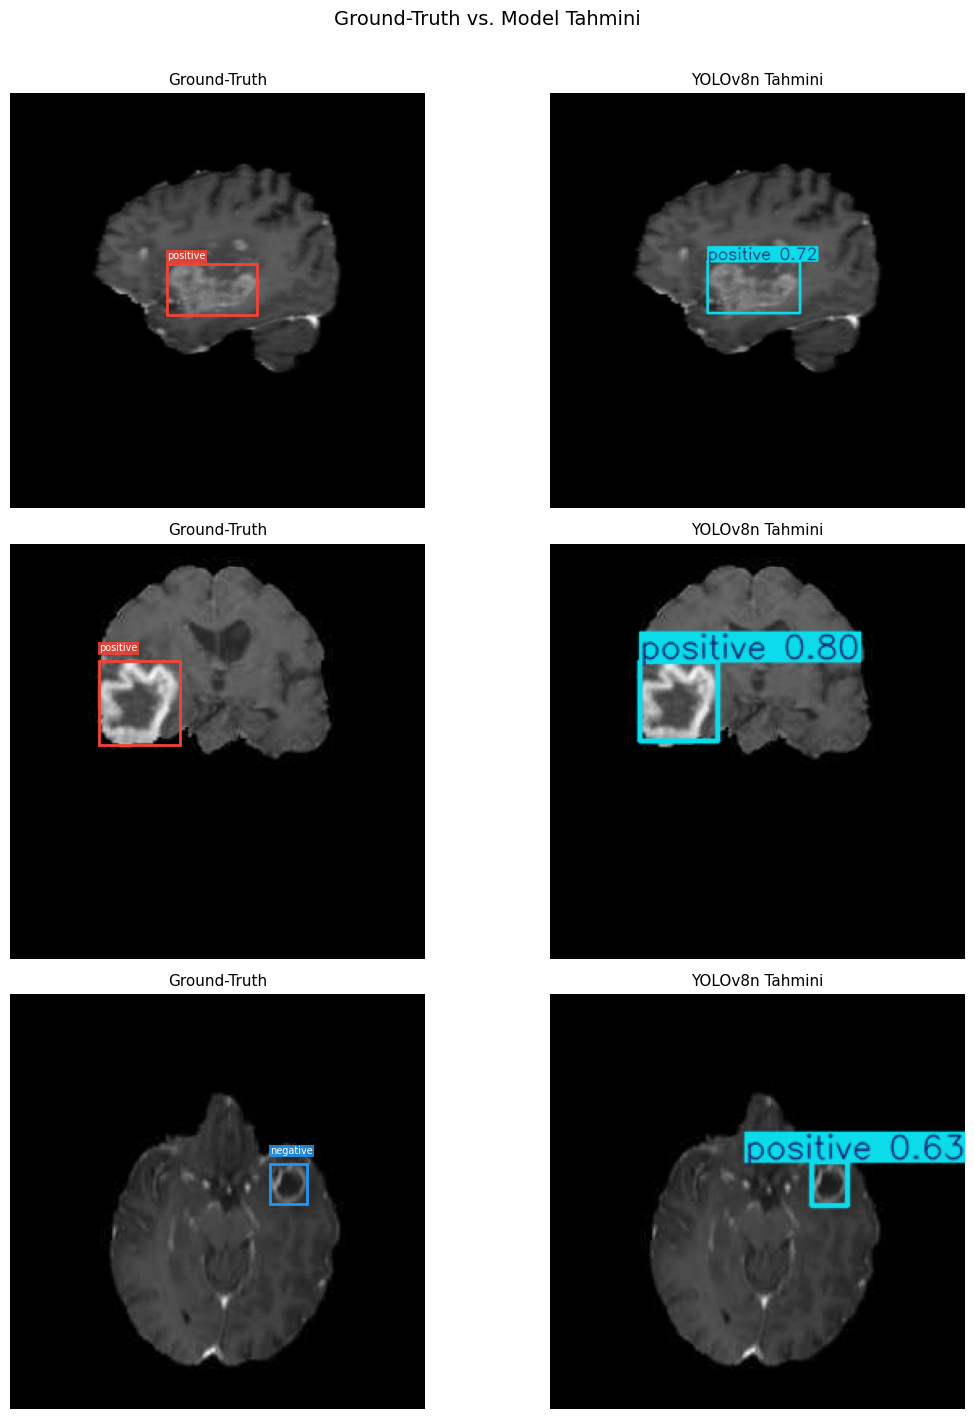

In [76]:
# Tahmin vs. Ground-Truth karşılaştırması (ilk 3 görüntü)
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for i, (result, img_path) in enumerate(zip(predict_results[:3], sample_val_imgs[:3])):
    ax_gt   = axes[i][0]
    ax_pred = axes[i][1]

    # Ground-truth
    lbl_path = VAL_LBL_DIR / (img_path.stem + '.txt')
    draw_boxes_on_ax(img_path, lbl_path, ax_gt)
    ax_gt.set_title('Ground-Truth', fontsize=11)

    # Tahmin
    annotated = result.plot()[:, :, ::-1]
    ax_pred.imshow(annotated)
    ax_pred.axis('off')
    ax_pred.set_title('YOLOv8n Tahmini', fontsize=11)

plt.suptitle('Ground-Truth vs. Model Tahmini', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Sonuç Özeti

### Proje Özeti

Bu çalışmada, Ultralytics'in sağladığı Brain Tumor Detection veri seti üzerinde **YOLOv8n** modeli transfer öğrenme yöntemiyle eğitilmiş ve MR görüntülerinde beyin tümörü tespiti gerçekleştirilmiştir.

### Metodoloji
- **Model:** YOLOv8n (nano) — COCO ağırlıklarından fine-tuning
- **Epoch:** 100
- **Görüntü boyutu:** 640x640
- **Batch boyutu:** 16
- **Veri artırma:** Ultralytics varsayılan augmentasyon (mosaic, horizontal flip, HSV(renkleri jitter), translate, scale, random erasing ve RandAugment -> args.yaml'dan bakıldı)

### Temel Bulgular
Eğitim sonrası elde edilen sonuçlar aşağıdaki tablodan görülebilir. 

In [77]:
# Tüm metriklerin nihai özet tablosu
print("\n" + "=" * 50)
print(" YOLOv8n Beyin Tümörü Tespiti — Nihai Sonuçlar")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)
print(f"En iyi model ağırlıkları: {best_weights}")


 YOLOv8n Beyin Tümörü Tespiti — Nihai Sonuçlar
              Metrik  Değer
 Doğruluk (Accuracy) 0.3196
Kesinlik (Precision) 0.4618
 Duyarlılık (Recall) 0.8283
            F1 Skoru 0.5930
             mAP@0.5 0.5380
        mAP@0.5:0.95 0.3819
En iyi model ağırlıkları: C:\Users\sinan\Documents\Python Projects\main_proj\deep_learning\final_proj\runs\detect\runs\brain_tumor_yolov8n\weights\best.pt
